# Lecture 3 (Variational data assimilation)

## Learning Objectives

By the end of this lecture, you will be able to:

- Describe the key components of a variational (3DVar/3DEnVar) YAML configuration, including cost function, background error, minimization, and output sections, and how they extend the HofX YAML

- Set up and run a JEDI variational application using `fv3jedi_var.x` with appropriate processor layout and input files

- Interpret the feedback file produced by a variational run, including groups with 0/1 suffixes (e.g., `hofx0` vs `hofx1`, `EffectiveQC0` vs `EffectiveQC1`) and departure diagnostics (`ombg`, `oman`)

- Visualize and compare observation-minus-background (ombg) and observation-minus-analysis (oman) fields to assess the impact of assimilation

- Read and plot analysis increments on a lat/lon grid and understand how column observation increments are distributed vertically through the adjoint of the observation operator

<div style="text-align: center;">
    <img src="./figures/jedi_components.png" width="75%">
</div>

# 3D(En)Var application in JEDI

* Similar to the HofX example, for variational case you run the relevant JEDI executable, `fv3jedi_var.x`, with a YAML input file.
* The YAML is similar to the HofX YAML input file with additional sections that specify details about the `cost function`, `analysis variables`, `background error`, `variational` and minimization, and `output` files. Let's review an example below:

```yaml
cost function:
  cost type: 3D-Var
  analysis variables: &avars
  - volume_mixing_ratio_of_no2

  # This section is similar to HofX yaml
  time window:
    begin: '2023-08-09T15:00:00Z'
    length: PT6H

  geometry:
    fms initialization:
      namelist filename: inputs/geometry_input/fmsmpp.nml
      field table filename: inputs/geometry_input/field_table_gfdl
    akbk: inputs/geometry_input/akbk72.nc4
    layout:
    - 2
    - 2
    npx: 91
    npy: 91
    npz: 72
    
  background:
    datetime: 2023-08-09T18:00:00Z
    filetype: cube sphere history
    datapath: inputs/backgrounds/bkg/c90
    filename: CF2.geoscf_jedi.20230809T180000Z.nc4
    max allowable geometry difference: 0.1

    state variables: &statevars
    - air_pressure_thickness
    - volume_mixing_ratio_of_no2
    - volume_mixing_ratio_of_no
    - volume_mixing_ratio_of_o3
    - volume_mixing_ratio_of_co
    - air_pressure_at_surface
    - water_vapor_mixing_ratio_wrt_moist_air
    field io names: &field_io_names
      air_pressure_thickness: DELP
      volume_mixing_ratio_of_no2: NO2
      volume_mixing_ratio_of_no: "NO"
      volume_mixing_ratio_of_o3: O3
      volume_mixing_ratio_of_co: CO
      air_pressure_at_surface: PS
      water_vapor_mixing_ratio_wrt_moist_air: SPHU

  observations:
    observers:
    - obs space:
        name: tempo_no2_tropo
        obsdatain:
          engine:
            obsfile: ../inputs/obs/tempo_no2_tropo_20230809T150000Z.nc
            type: H5File
        obsdataout:
          engine:
            allow overwrite: true
            obsfile: outputs/fb.tempo_no2_tropo.20230809T150000Z_3dvar_IB.nc
            type: H5File
        observed variables:
        - nitrogendioxideColumn
        simulated variables:
        - nitrogendioxideColumn
      obs filters:
      - filter: RejectList
        where:
        - variable:
            name: MetaData/cloud_fraction
          minvalue: 0.15
      - filter: RejectList
        where:
        - variable:
            name: MetaData/solar_zenith_angle
          minvalue: 70
      obs operator:
        name: ColumnRetrieval
        nlayers_retrieval: 72
        tracer variables:
        - volume_mixing_ratio_of_no2
        isApriori: false
        isAveragingKernel: true
        stretchVertices: topbottom


  # background information needed for variational task
  # Here is an example for a simple Identity operator
  background error:
    covariance model: SABER
    saber central block:
      saber block name: ID

output:
  filetype: cube sphere history
  datapath: outputs/
  max allowable geometry difference: 0.1
  filename: 3dvar_IB.geos_cf.an.20230809_1800z.nc4
  first: PT0H
  frequency: PT1H
  field io names: *field_io_names
variational:
  minimizer:
    algorithm: DRPCG
  iterations:
  - ninner: 100
    gradient norm reduction: 1e-10
    geometry:
      akbk: inputs/geometry_input/akbk72.nc4
      # np must be = 2x2x6 = 24
      layout: 
      - 2
      - 2
      npx: 91
      npy: 91
      npz: 72
    diagnostics:
      departures: ombg

final:
  diagnostics:
    departures: oman

  # optional output to lat/lon grid
  increment to structured grid:
    grid type: latlon
    local interpolator type: oops unstructured grid interpolator
    resolution in degrees: 1
    variables to output:
    - volume_mixing_ratio_of_no2
    pressure levels in hPa:
    - 800
    - 500
    - 100
    #bottom model level: true
    all model levels: true
    datapath: outputs/
    type: inc
    exp: 3dvar_IB
      
```

A few things about the YAML:

* By default, `fv3jedi_var.x` writes out: "analysis" file(s) in model space cubed-sphere grid and feedback file(s) in observation space (IODA format). Optionally, users can also write increments in cubed-sphere (not shown in this example) or lat/lon grid (set in `increment to structured grid` and used in this example).
  
* For this example we are using a simple Identity B. This is far from an ideal solution and is only used in this example to simplify the problem and the input YAML file. When reviewing the outputs later in this lecture, we run a 3DEnVar in which the background error covariance B is estimated using a 32-member ensemble.

* The "layout" is set to 2x2. For an FV3 application, the number of processors required to run a job must be a multiple of 6. This means that for the layout of 2x2, 2x2x6=24 processors are needed. One can request one node with 24 processors. Details about submitting a job to Discover is available [here](https://mer-a-o.github.io/howtojedi/discover/#option-1-submit-a-job). To run this exercise, you will need to set `ntasks-per-node` and `-n` both to 24. 

In the `submit.sh`, after setting the SLURM variables and loading the environment the command below runs the JEDI executable:

The input files for this exercise are available on Discover `/discover/nobackup/mabdiosk/JEDI_practicals/live_demo/var`. `submit.sh` sets the SLURM variables and loads the JEDI enviroment. Then it runs the JEDI executable using:

```
$MPIEXEC "-n" "24" $JEDI_BUILD/fv3jedi_var.x 3denvar_geos_cf_c90_ensB.yaml
```

* Compare `3denvar_geos_cf_c90_ensB.yaml` with the input YAML described in this lecture (`3dvar_geos_cf_c90_IB.yaml`) and note how `background error` are different.

Running the variational application using this input YAML file will produce 4 output files.
1. Feedback file in observation space.
2. Analysis file in model space (cubed-sphere).
3. Optional increment files in model space (lat/lon) at `modelLevels` and 4. `pressureLevels` as requested in `increment to structured grid` section.

Let's review each of these files. Outputs shown below are from a separate 3DEnVar run, YAML available at `/discover/nobackup/mabdiosk/JEDI_practicals/live_demo/var/3denvar_geos_cf_c90_ensB.yaml`. Details about different options for `background error` will be discussed in a future lecture. 

## Feedback file
This file is similar to the feedback file discussed in the HofX lecture with additional "Groups" that were computed and added during the execution of "variational" tasks. 

In [ ]:
def print_groups(ioda_filename):
    # Loop through each group in the file
    for group_name in ioda_filename.groups:
        print(f"\n=== Group: {group_name} ===")
    
        group = ioda_filename[group_name]
    
        # List data variables
        if group.data_vars:
            print("  Data variables:")
            for var in group.data_vars:
                print(f"    - {var}")
        else:
            print("  Data variables: None")

import xarray as xr
live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
obs_filename = f'{live_demo_path}/var/outputs/fb.tempo_no2_tropo.20230809T150000Z_3denvar.nc'
obs_file = xr.open_datatree(obs_filename)
print_groups(obs_file)


=== Group: / ===
  Data variables: None

=== Group: /EffectiveError0 ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /EffectiveError1 ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /EffectiveQC0 ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /EffectiveQC1 ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /MetaData ===
  Data variables:
    - cloud_fraction
    - dateTime
    - longitude
    - latitude
    - quality_assurance_value
    - solar_zenith_angle
    - albedo
    - viewing_zenith_angle

=== Group: /ObsBias0 ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /ObsBias1 ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /ObsError ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /ObsValue ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /PreQC ===
  Data variables:
    - nitrogendioxideColumn

=== Group: /RetrievalAncillaryData ===
  Data variables:
    - averagingKernel
    - 

Some Group names have a suffix of 0 or 1, such as `EffectiveQC0` and `EffectiveQC1`, `hofx0` and `hofx1`. Group names with 0 refer to values prior to the variational analysis (i.e., using the background), while group names with 1 refer to values after the variational analysis (i.e., using the analysis). For example, `hofx0` refers to H(x) values computed using the background as input, and `hofx1` refers to values computed using the analysis as input.

Additional Groups include `ombg`, which refers to observation-minus-background (obs - background), and `oman`, which refers to observation-minus-analysis (obs - analysis).

Let's plot `ombg` and `oman`:

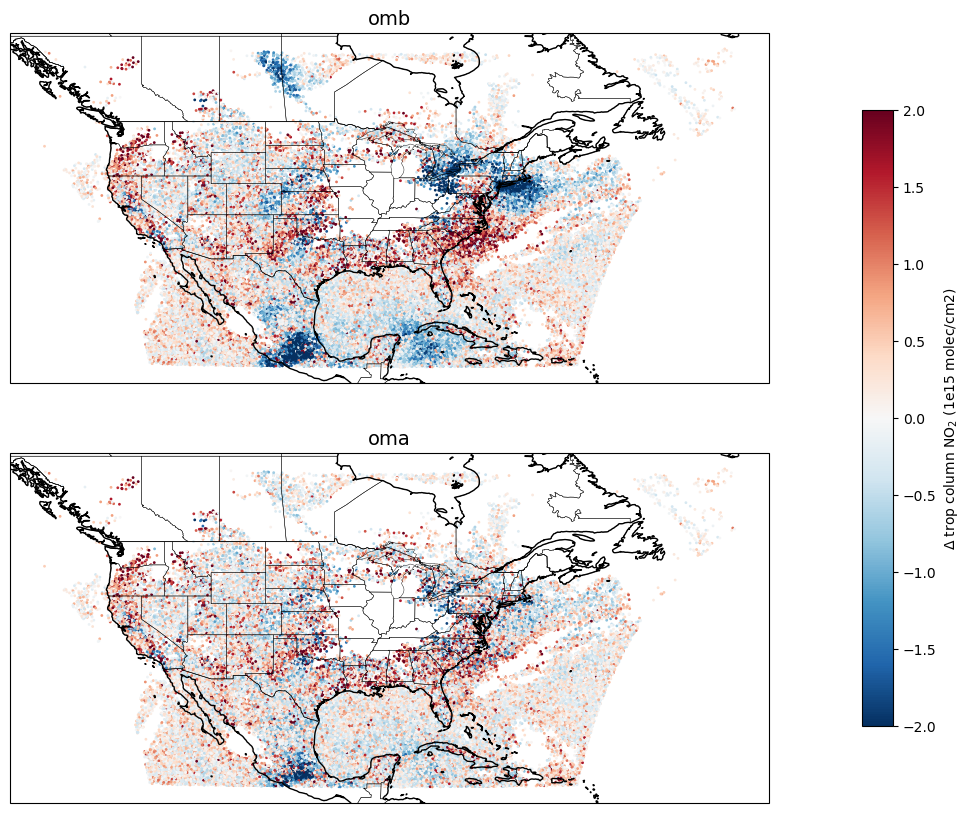

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd

def read_fb(fname,var_name,conv):
    
    fb_file = xr.open_datatree(fname)
    ombg = fb_file['ombg'][var_name]*conv
    oman = fb_file['oman'][var_name]*conv
    lat = fb_file['MetaData']['latitude']
    lon = fb_file['MetaData']['longitude']
    time = fb_file['MetaData']['dateTime']
    qc = fb_file['EffectiveQC0'][var_name]
    
    data = pd.DataFrame({
        'time': time, 
        'lat': lat, 
        'lon': lon, 
        'ombg': ombg,
        'oman': oman,
        'qc' : qc,
    })
    data_df = pd.DataFrame(data)
    return data_df


live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
data_dir = f'{live_demo_path}/var/outputs'
fname = 'fb.tempo_no2_tropo.20230809T150000Z_3denvar.nc'

conv = 60221.4076
unit = '(1e15 molec/cm2)'
var_name = 'nitrogendioxideColumn'

data_df = read_fb(f'{data_dir}/{fname}', var_name, conv)

# Only plot points that passed QC
data_df = data_df[data_df['qc']==0]

# ----- Plotting -----
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(15, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Common map features
for ax in axes:
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)

# Shared color scale for differences
norm_diff = colors.TwoSlopeNorm(vcenter=0, vmin=-2, vmax=2)
cmap_diff = 'RdBu_r'
msize = 1

# ---- Panel 1: obs - hofx0 ----
sc0 = axes[0].scatter(
    data_df['lon'], data_df['lat'],
    c=data_df['ombg'],
    s=msize, cmap=cmap_diff, norm=norm_diff,
    transform=ccrs.PlateCarree()
)
axes[0].set_title('omb', fontsize=14)

# ---- Panel 2: hofx1 - obs ----
sc1 = axes[1].scatter(
    data_df['lon'], data_df['lat'],
    c=data_df['oman'],
    s=msize, cmap=cmap_diff, norm=norm_diff,
    transform=ccrs.PlateCarree()
)
axes[1].set_title('oma', fontsize=14)

# ---- Shared colorbar ----
cbar = fig.colorbar(
    sc1, ax=axes,
    orientation='vertical',
    pad=0.08, shrink=0.8
)
cbar.set_label(f'Δ trop column NO$_2$ {unit}')

plt.show()

## Analysis and Increment files

* Analysis file is created at the middle of the window (3Dvar). This file is in cubed-sphere grid.
* Increments can be calculated by subtracting background values from analysis values (`inc = an - bg`).
* To make the post processing simpler JEDI has an optional feature to write out increment values in cubed-sphere or in lat/lon grid.

Let's plot a map of surface NO2 increments. Note that we limited the increment map to CONUS region because TEMPO observation is only available over North America. Increment values outside of this area are expected to be zero.

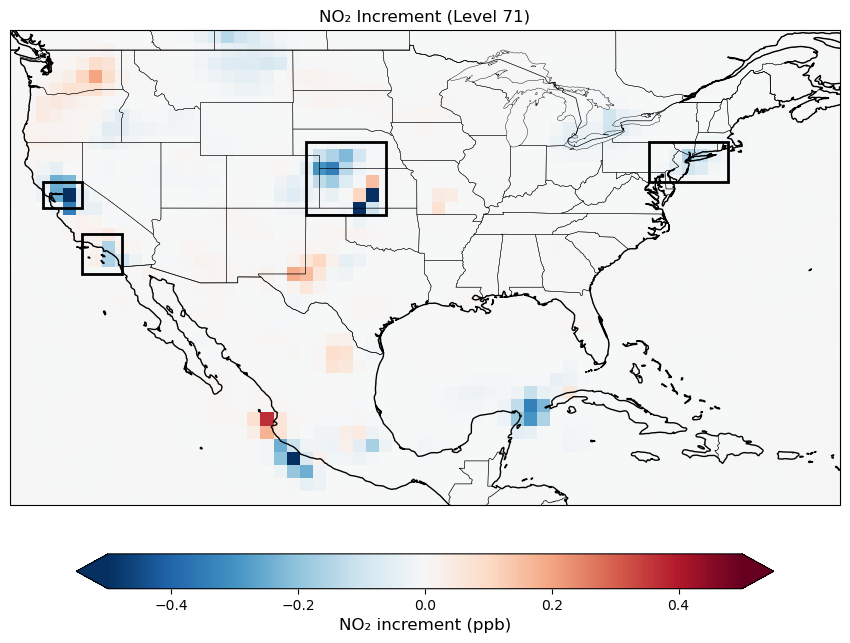

In [ ]:
# Plotting increments at surface (model space)
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches


def read_latlon(fname, var_name, conv,
                lat_min, lat_max, lon_min, lon_max,
                lev=None):

    """
    Read a variable from a lat/lon file, and subset it
    within a specified bounding box and optional vertical level.
    """

    f = xr.open_dataset(fname)
    var = f[var_name] * conv

    var = var.assign_coords(
        longitude=(((var.longitude + 180) % 360) - 180)
    )
    var = var.sortby('longitude')

    var_box = var.sel(
        latitude=slice(lat_max, lat_min),
        longitude=slice(lon_min, lon_max)
    )

    # Select level only if requested
    if lev is not None:
        var_box = var_box.isel(levels=lev)

    return var_box


conv = 1e9
unit = 'ppb'
var_name = 'volume_mixing_ratio_of_no2'
live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
inc_path = f'{live_demo_path}/var/outputs'

# plotting CONUS
lat_min, lat_max = 15, 50
lon_min, lon_max = -125, -63

lev = 71  # Surface

fname_3denvar = '3denvar.inc.2023-08-09T18:00:00Z.latlon.modelLevels.nc'
inc_3denvar = read_latlon(f'{inc_path}/{fname_3denvar}',var_name, conv, lat_min, lat_max, lon_min, lon_max, lev)


vmin = -0.5
vmax = 0.5

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

pcm = inc_3denvar.plot(ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )


## Add boxes to look at vertical structure of increment in these boxes

# Region 1 -- Kansas
lat_min, lat_max = 36.5, 42
lon_min, lon_max = -103.0, -97

# Draw bounding box
rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner (lon, lat)
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    fill=False,
    edgecolor='black',
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(rect)


# Region 2 -- LA basin
lat_min, lat_max = 32, 35
lon_min, lon_max = -120, -117

# Draw bounding box
rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner (lon, lat)
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    fill=False,
    edgecolor='black',
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(rect)


# Region 3 -- SF
lat_min, lat_max = 37, 39
lon_min, lon_max = -123, -120

# Draw bounding box
rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner (lon, lat)
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    fill=False,
    edgecolor='black',
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(rect)


# Region 4 -- LongIsland
lat_min = 39
lat_max = 42
lon_min = -77
lon_max = -71

# Draw bounding box
rect = mpatches.Rectangle(
    (lon_min, lat_min),                 # lower-left corner (lon, lat)
    lon_max - lon_min,                  # width
    lat_max - lat_min,                  # height
    fill=False,
    edgecolor='black',
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.add_patch(rect)


#ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.set_title(f'NO₂ Increment (Level {lev})', fontsize=12)

cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation='horizontal',
    shrink=0.6,
    pad=0.08,
    extend='both'
)
cbar.set_label('NO₂ increment (ppb)', fontsize=12)

plt.show()

### Vertical structure of increments

Note that the observed quantity is "tropospheric column NO₂". The `ColumnRetrieval` observation operator takes NO₂ mixing ratios at each level and calculates the "tropospheric column NO₂" at observation locations. During the minimization, the adjoint of the observation operator maps information from the column observations back to 3D NO₂ mixing ratio increments at each model level. Therefore, we expect to see increments not only at the surface but also at higher levels, reflecting the vertical sensitivity of the tropospheric column retrievals. Let's review the vertical structure of the increments at regions (boxes) shown in the previous map.

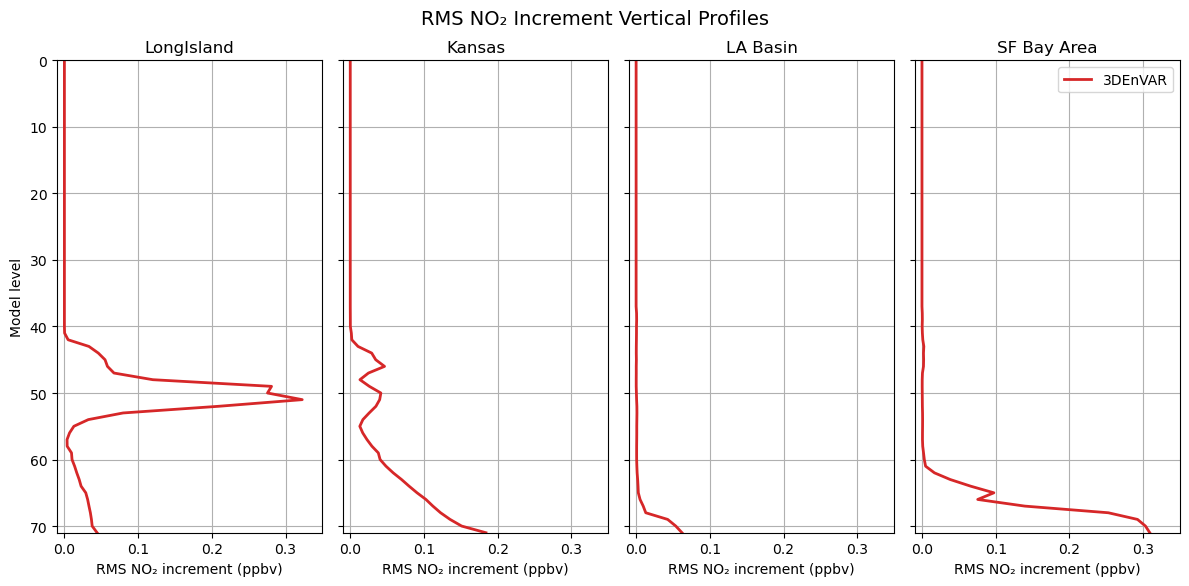

In [ ]:
# Vertical distribution of increment


live_demo_path = '/discover/nobackup/mabdiosk/JEDI_practicals/live_demo'
inc_path = f'{live_demo_path}/var/outputs'


conv = 1e9
unit = 'ppb'
var_name = 'volume_mixing_ratio_of_no2'

fname_3denvar = '3denvar.inc.2023-08-09T18:00:00Z.latlon.modelLevels.nc'

# -------------------------
# Define regions
# -------------------------
regions = [
    {
        'name': 'LongIsland',
        'lat_min': 39, 'lat_max': 42,
        'lon_min': -77, 'lon_max': -71
    },
    {
        'name': 'Kansas',
        'lat_min': 36.5, 'lat_max': 42.0,
        'lon_min': -103.0, 'lon_max': -97.0
    },
    {
        'name': 'LA Basin',
        'lat_min': 32.0, 'lat_max': 35.0,
        'lon_min': -120.0, 'lon_max': -117.0
    },
    {
        'name': 'SF Bay Area',
        'lat_min': 37.0, 'lat_max': 39.0,
        'lon_min': -123.0, 'lon_max': -120.0
    },
]

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=4,
    figsize=(12, 6),
    sharey=True
)

# -------------------------
# Loop over regions
# -------------------------
for ax, reg in zip(axes, regions):
    inc_3denvar = read_latlon(
        f'{inc_path}/{fname_3denvar}',
        var_name, conv,
        reg['lat_min'], reg['lat_max'],
        reg['lon_min'], reg['lon_max']
    )

    rms_3denvar = (inc_3denvar**2).mean(dim=['latitude', 'longitude'])**0.5

    ax.plot(
        rms_3denvar, rms_3denvar.levels,
        label='3DEnVAR',
        color='tab:red',
        linewidth=2
    )

    ax.set_title(reg['name'], fontsize=12)
    ax.set_xlim(-0.01,0.35)
    ax.grid(True)

# -------------------------
# Axis labels & legend
# -------------------------
axes[0].set_ylabel('Model level')
for ax in axes:
    ax.set_xlabel('RMS NO₂ increment (ppbv)')
    ax.set_ylim(71, 0)

axes[-1].legend(loc='upper right')

fig.suptitle(
    'RMS NO₂ Increment Vertical Profiles',
    fontsize=14,
    y=0.97
)

plt.tight_layout()
plt.show()


The difference in the vertical structure of NO₂ increments across regions comes from several interacting factors in the 3DEnVar system:

* With ensemble-based background error covariance, we have flow dependencies which can vary by region. The ensemble B controls how a column increment gets distributed vertically. 

* TEMPO retrieves tropospheric column NO₂ using averaging kernels that describe the retrieval's sensitivity at each level. This sensitivity depends on surface reflectance, albedo, viewing geometry, and aerosol/cloud properties, which may vary by region. The adjoint of the `ColumnRetrieval` operator projects column-space increments back to model levels weighted by these kernels.

## Reviewing the Log File

Running any JEDI executable generates an output log that contains useful information about the job, such as a summary of input values, geometry details, a list of all tasks executed, and timing statistics for each task. When running a variational application, additional information about the minimization process is included in the log, which can be examined to ensure convergence is achieved.

Searching for `Quadratic cost function` in the log file shows how the cost function and its components changed during each iteration of the minimization. The figure below was created using this log output.

<div style="text-align: center;">
    <img src="./figures/cost_function_convergence.png">
</div>

The four panels above provide a views of the variational minimization process and how JEDI finds the optimal analysis that balances fitting observation with the background.

#### Panel 1: Total Cost Function (J)
The total cost function is what we're minimizing:

$$J = J_b + J_o$$

where $J_b$ penalizes departures from the background and $J_o$ penalizes misfit to observations.

In the total cost function figure we expect:

* Smooth, monotonic decrease which means The minimizer is working correctly.
* Significant reduction (20-40%) which means observations are providing useful information.
* Convergence to plateau which means Optimal solution has been found.

If $J$ increases, oscillates, or shows only small reduction, there may be issues with the configuration (B/R matrices, observation operator, or minimizer settings).


#### Panel 2 and 3: Background vs Observation Terms (Jb and Jo)

$J_b$ (blue) measures how far the analysis deviates from the background state and $J_o$ (orange) measures how well the analysis fits the observations.

$$J_b = (\mathbf{x} - \mathbf{x}_b)^T \mathbf{B}^{-1} (\mathbf{x} - \mathbf{x}_b)$$

$$J_o = (\mathbf{y} - H(\mathbf{x}))^T \mathbf{R}^{-1} (\mathbf{y} - H(\mathbf{x}))$$

In this figure we expect:
* $J_b$ to start at 0 which means at iteration 0, analysis = background  
* $J_b$ to increase gradually which means analysis is adjusting to accommodate observations  
* $J_o$ to decrease significantly which means the observations are being successfully assimilated
* Both terms plateau together

#### Panel 4: Gradient Norm Reduction

Norm reduction is a measure of how close you are to the minimum of the cost function.

In the input YAML number of iteration (`ninner`) is set to 100 and `gradient norm reduction` is set to 1e-10. 
Minimization stops after 100 iterations or when: norm_reduction < $10^{-10}$, whichever happens first. 

In the gradient norm reduction plot we expect:
* Smooth exponential decrease (linear on log scale)  
* Crosses the threshold ($10^{-10}$) within reasonable iterations (<100)  
* Convergence achieved (marked by green line)

## Ctest examples

There are many ctests examples on `fv3-jedi` repository that text different implementations of `fv3jedi_var.x`. Let's review a few of them together. In [test/CMakeLists.txt](https://github.com/JCSDA/fv3-jedi/blob/master/test/CMakeLists.txt) search for `fv3jedi_var.x` to see all the ctests that use this executable (there's a lot!). There are 3DVar, hybrid 3DVar, 3DFGat, 4D, etc. ctests and they all use the same JEDI executable. Let's compare the YAML files to see how variational task can be implemented differently without the need to build separate execuables. 

Let's compare a hybrid 3DVar with a hybrid 4DEnVar togthere:

```
ecbuild_add_test( TARGET   fv3jedi_test_tier1_hyb-3dvar_geos_sondes
                  MPI      6
                  ARGS     testinput/hyb-3dvar_geos_sondes_c12.yaml
                  COMMAND  fv3jedi_var.x )


ecbuild_add_test( TARGET   fv3jedi_test_tier2_hyb-4denvar_geos_sondes
                  MPI      6
                  ARGS     testinput/hyb-4denvar_geos_sondes_c12.yaml
                  COMMAND  fv3jedi_var.x )
```

Input YAML files are available for [hybrid 3DVar](https://github.com/JCSDA/fv3-jedi/blob/develop/test/testinput/hyb-3dvar_geos_sondes_c12.yaml) and [hybrid 4DEnVar](https://github.com/JCSDA/fv3-jedi/blob/develop/test/testinput/hyb-4denvar_geos_sondes_c12.yaml). Note the differences in these YAML files. 

